# 01 — Determinism and Physics

Phionyx Core treats the LLM as a **sensor**, not an oracle. Cognitive state
is held in a small physics layer that is *strictly deterministic*: same
inputs, same outputs, byte for byte.

This notebook walks through the substrate and proves that property.

**Public API used:** `EchoState2`, `calculate_phi_v2_1`,
`calculate_phi_cognitive`, `calculate_phi_physical`,
`calculate_entropy_shannon`.


## 1. Imports and version check

In [1]:
import hashlib
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np

import phionyx_core
from phionyx_core import (
    EchoState2,
    calculate_phi_v2_1,
    calculate_phi_cognitive,
    calculate_phi_physical,
    calculate_entropy_shannon,
)

print("phionyx_core:", phionyx_core.__version__)
print("python:     ", sys.version.split()[0])


phionyx_core: 0.2.0
python:      3.12.3


## 2. `EchoState2` — primary state vector

Three primary attributes (`A`, `V`, `H`) plus derived properties. Derived
metrics (`resonance`, `stability`) are computed on demand and never stored
— that keeps the canonical state minimal and reproducible.


In [2]:
state = EchoState2(A=0.6, V=0.3, H=0.4)

print("Primary state")
print(f"  arousal  A = {state.A}")
print(f"  valence  V = {state.V}")
print(f"  entropy  H = {state.H}")

print("\nDerived (computed, not stored)")
print(f"  resonance = {state.resonance:.4f}")
print(f"  stability = {state.stability:.4f}")


Primary state
  arousal  A = 0.6
  valence  V = 0.3
  entropy  H = 0.4

Derived (computed, not stored)
  resonance = 0.4800
  stability = 0.6000


## 3. Phi v2.1 — Hybrid Resonance Model

`calculate_phi_v2_1` returns a dict with the total Phi plus the cognitive
and physical components and the (auto-normalized) weights.

$$\Phi_{total} = w_c \cdot \Phi_{cognitive} + w_p \cdot \Phi_{physical}$$


In [3]:
phi = calculate_phi_v2_1(
    valence=state.V,
    arousal=state.A,
    amplitude=state.A * 10.0,
    time_delta=0.1,
    gamma=0.15,
    stability=state.stability,
    entropy=state.H,
    w_c=0.6,
    w_p=0.4,
)

for k, v in phi.items():
    print(f"  {k:<18} {v:.4f}")


  phi                1.5250
  phi_cognitive      0.1774
  phi_physical       3.5464
  weight_cognitive   0.6000
  weight_physical    0.4000


## 4. Determinism proof — 1000 runs, one unique output

Run the same calculation 1000 times. The set of unique results must have
size 1. If anything in the substrate were stochastic, this would be > 1.


In [4]:
inputs = dict(
    valence=0.5, arousal=0.7, amplitude=5.0, time_delta=1.0,
    gamma=0.15, stability=0.9, entropy=0.3, w_c=0.75, w_p=0.25,
)

results = {round(calculate_phi_v2_1(**inputs)["phi"], 12) for _ in range(1000)}
print(f"unique phi values across 1000 runs: {len(results)}")
print(f"phi = {next(iter(results))}")

assert len(results) == 1, "Phi must be deterministic"


unique phi values across 1000 runs: 1
phi = 1.065914479372


## 5. Base Life Support — negative valence still resonates

In v2.2 the formula was hardened so a sustained-stress (negative valence)
state cannot collapse Phi to zero. Useful for any agent that has to keep
operating under pressure rather than freezing.


In [5]:
print(f"{'valence':>8} | {'phi_cognitive':>13} | {'phi_total':>10}")
print("-" * 40)
for v in [-1.0, -0.5, 0.0, 0.5, 1.0]:
    r = calculate_phi_v2_1(
        valence=v, arousal=0.5, amplitude=5.0, time_delta=0.1,
        gamma=0.15, stability=0.9, entropy=0.3, w_c=0.6, w_p=0.4,
    )
    print(f"{v:>8.2f} | {r['phi_cognitive']:>13.4f} | {r['phi']:>10.4f}")


 valence | phi_cognitive |  phi_total
----------------------------------------
   -1.00 |        0.7448 |     1.4320
   -0.50 |        0.4171 |     1.2353
    0.00 |        0.0894 |     1.0387
    0.50 |        0.4171 |     1.2353
    1.00 |        0.7448 |     1.4320


## 6. Valence × Arousal heatmap

A 41 × 41 grid of `phi_cognitive` over the full Circumplex space. Smooth,
reproducible, and bounded — no out-of-distribution surprises.


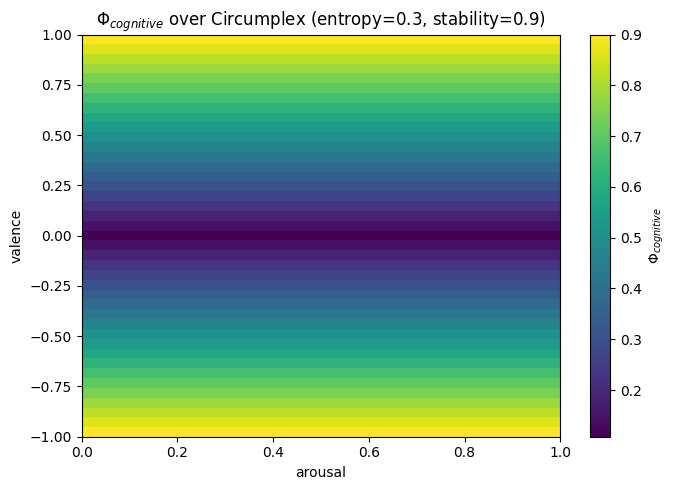

In [6]:
val_grid = np.linspace(-1.0, 1.0, 41)
aro_grid = np.linspace(0.0, 1.0, 41)
heat = np.zeros((len(val_grid), len(aro_grid)))

for i, v in enumerate(val_grid):
    for j, a in enumerate(aro_grid):
        heat[i, j] = calculate_phi_cognitive(entropy=0.3, stability=0.9, valence=float(v))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    heat, origin="lower", aspect="auto",
    extent=[aro_grid[0], aro_grid[-1], val_grid[0], val_grid[-1]],
    cmap="viridis",
)
ax.set_xlabel("arousal")
ax.set_ylabel("valence")
ax.set_title(r"$\Phi_{cognitive}$ over Circumplex (entropy=0.3, stability=0.9)")
fig.colorbar(im, ax=ax, label=r"$\Phi_{cognitive}$")
plt.tight_layout()
plt.show()


## 7. Comparison — deterministic substrate vs naive noisy alternative

Imagine a "Phi-shaped" function that adds Gaussian noise on every call.
Run it 200 times and compare the spread to the deterministic `phi_v2_1`.


deterministic spread: 0.000000
noisy spread:         0.247785


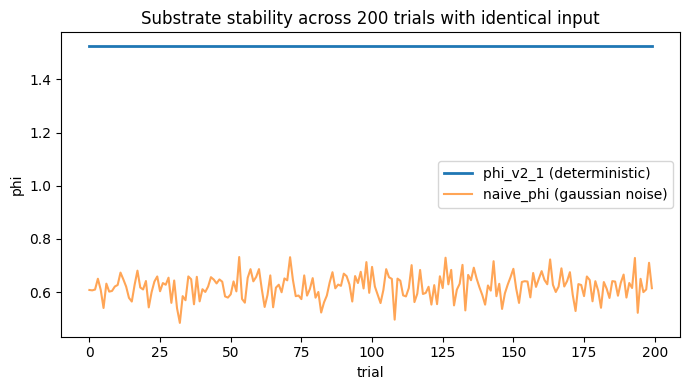

In [7]:
rng = random.Random(42)

def naive_phi(state: EchoState2) -> float:
    base = 0.5 * state.A + 0.3 * (state.V + 1) / 2 + 0.2 * (1 - state.H)
    return base + rng.gauss(0, 0.05)  # 5% noise

s = EchoState2(A=0.6, V=0.3, H=0.4)

deterministic = [
    calculate_phi_v2_1(
        valence=s.V, arousal=s.A, amplitude=s.A * 10, time_delta=0.1,
        gamma=0.15, stability=s.stability, entropy=s.H, w_c=0.6, w_p=0.4,
    )["phi"]
    for _ in range(200)
]
noisy = [naive_phi(s) for _ in range(200)]

print(f"deterministic spread: {max(deterministic) - min(deterministic):.6f}")
print(f"noisy spread:         {max(noisy) - min(noisy):.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(deterministic, label="phi_v2_1 (deterministic)", linewidth=2)
ax.plot(noisy, label="naive_phi (gaussian noise)", alpha=0.7)
ax.set_xlabel("trial")
ax.set_ylabel("phi")
ax.set_title("Substrate stability across 200 trials with identical input")
ax.legend()
plt.tight_layout()
plt.show()


## What this proves

- The state vector is small and fully introspectable.
- Every Phi computation is reproducible bit-for-bit.
- Negative-valence regimes do not collapse the cognitive layer.
- The whole physics layer is pure math — no LLM, no I/O, no clock.

This is the substrate. The next notebook (02) shows how the runtime layers
governance gates on top of it.
